# 🌫️ Predicting Air Quality Using Machine Learning

This project aims to analyze air quality data in India to gain insights into pollution levels, their spatial and temporal variations, and potential contributing factors. By examining trends and patterns in air quality measurements, the project seeks to understand the impact of pollution on public health and the environment, and inform strategies for pollution mitigation and environmental policy.

---

## 🚀 Project Workflow

We will follow these steps throughout the project:

1. **Problem Definition**  
2. **Data Definition**  
3. **Data Exploration**  
4. **Data Preprocessing**  
5. **Feature Engineering**  
6. **Model Selection**  
7. **Model Training**  
8. **Model Evaluation**  
9. **Hyperparameter Tuning**  
10. **Model Interpretation**

📂 **Dataset Link:** [Air Quality Data in India (Kaggle)](https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india)

---

## 1️⃣ Problem Definition

This problem encompasses tasks such as data collection, preprocessing, exploratory data analysis, feature engineering, statistical analysis, machine learning modeling, and visualization. The ultimate goal is to leverage data-driven insights to address challenges related to air pollution and promote sustainable development and public well-being in India.

---

## 2️⃣ Data Definition

### **1. City**
- Categorical variable representing the city where air quality measurements were recorded.  
- Example values: *Delhi, Mumbai, Bangalore, Chennai*  
- Cities differ in size, industrial activity, traffic, geography—factors that influence air quality.

---

### **2. Date**
- Temporal variable representing the date of the air quality measurement.  
- Example values: *"2022-01-01", "2022-01-02"*  
- Used in time-series analysis to identify trends and seasonal variation.

---

### **3. PM2.5 (Particulate Matter 2.5)**
- Fine particles ≤ 2.5µm that penetrate deep into the lungs.  
- Sources: vehicle emissions, industry, construction, biomass burning.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **4. PM10 (Particulate Matter 10)**
- Coarse particles ≤ 10µm, can irritate the respiratory tract.  
- Sources: dust, pollen, construction activities.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **5. NO (Nitric Oxide)**
- Produced by combustion processes (vehicles, industries).  
- Precursor to NO₂ and ozone.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **6. NO₂ (Nitrogen Dioxide)**
- Formed from NO in the atmosphere.  
- Emitted from exhausts, power plants; causes respiratory irritation.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **7. NOₓ (Nitrogen Oxides)**
- Group of gases including NO and NO₂.  
- Emitted from high-temperature combustion (vehicles, power plants).  
- Contributes to ozone and acid rain.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **8. NH₃ (Ammonia)**
- Emitted from fertilizers, livestock, wastewater plants.  
- Combines with other pollutants to form particulate matter.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **9. CO (Carbon Monoxide)**
- Produced by incomplete combustion (vehicles, biomass).  
- Toxic at high levels, interferes with oxygen transport.  
- Measured in ppm or mg/m³. Range: 0 to several ppm/mg/m³.

---

### **10. SO₂ (Sulfur Dioxide)**
- Produced by burning sulfur-rich fossil fuels.  
- Major pollutant from industries and power plants.  
- Causes respiratory issues, acid rain.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **11. O₃ (Ozone)**
- Ground-level ozone forms from reactions of NOₓ and VOCs under sunlight.  
- Major component of smog, harmful to lungs.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **12. Benzene**
- Industrial solvent, carcinogenic.  
- Found in vehicle exhaust, tobacco smoke.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **13. Toluene**
- Used in paints, adhesives.  
- Emitted by vehicles, industry.  
- Exposure affects the nervous system.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **14. Xylene**
- Used in industrial products.  
- Found in exhaust, smoke.  
- Exposure causes dizziness, nausea.  
- Measured in µg/m³. Range: 0 to several hundred.

---

### **15. AQI (Air Quality Index)**
- Standardized measure aggregating pollution levels into a single value.  
- Reflects health impact; range: 0 to 500.  
- Calculated from key pollutants (PM2.5, PM10, NO₂, SO₂, CO, O₃).  
- Discrete variable.

---

### **16. AQI_Bucket**
- Categorical representation of AQI:  
  *"Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"*  
- Makes AQI levels more interpretable for the public.

---

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

In [ ]:
import kaggle

# Download the dataset
kaggle.api.dataset_download_files(
    "rohanrao/air-quality-data-in-india", path=".", unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india


In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
np.random.seed(7)
%matplotlib inline

In [ ]:
df = pd.read_csv("city_day.csv", low_memory=False, parse_dates=["Date"])

In [ ]:
df = df.drop(labels=["NO", "NOx", "NH3", "Benzene", "Toluene", "Xylene"], axis=1)

In [ ]:
df.describe()

,Date,PM2.5,PM10,NO2,CO,SO2,O3,AQI
count,29531,24933.000000,18391.000000,25946.000000,27472.000000,25677.000000,25509.000000,24850.000000
mean,2018-05-14 05:40:15.807118080,67.450578,118.127103,28.560659,2.248598,14.531977,34.491430,166.463581
min,2015-01-01 00:00:00,0.040000,0.010000,0.010000,0.000000,0.010000,0.010000,13.000000
25%,2017-04-16 00:00:00,28.820000,56.255000,11.750000,0.510000,5.670000,18.860000,81.000000
50%,2018-08-05 00:00:00,48.570000,95.680000,21.690000,0.890000,9.160000,30.840000,118.000000
75%,2019-09-03 00:00:00,80.590000,149.745000,37.620000,1.450000,15.220000,45.570000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,362.210000,175.810000,193.860000,257.730000,2049.000000
std,NaN,64.661449,90.605110,24.474746,6.962884,18.133775,21.694928,140.696585


In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO2,CO,SO2,O3,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,18.22,0.92,27.64,133.36,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,15.69,0.97,24.55,34.06,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,19.30,17.40,29.07,30.70,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,18.48,1.70,18.59,36.08,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,21.42,22.10,39.33,39.31,NaN,NaN


## Data Cleaning

### Steps we are going to follow

1. Fill the missing values using interpolation
2. Drop the missing values if they remain
3. We have already dropped unnecessary columns: `NO`, `NOx`, ` NH3``Benzene `, `Toluene`, `Xylene`.
4. Remove outlier using InterQuartileRange(IQR)

Alongwith cleaning we will visualize the data to see the changes


In [ ]:
# Drop City, Date, AQI_Bucket
df = df.drop(labels=["AQI_Bucket"], axis=1)

In [ ]:
df1 = df[["City", "Date", "AQI", "PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]].copy()
columns_to_interpolate = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]
df1.sort_values(by=["City", "Date"], inplace=True)
df1[columns_to_interpolate] = (
    df1.groupby("City")[columns_to_interpolate]
    .apply(lambda group: group.interpolate(method="linear", limit_direction="both"))
    .reset_index(drop=True)
)  # Reset index after groupby

In [ ]:
df1.isna().sum()

City        0
Date        0
AQI      4681
PM2.5       0
PM10     2009
NO2         0
CO          0
SO2         0
O3        162
dtype: int64

In [ ]:
col = df.columns.to_list()
col.remove("AQI")
col.remove("City")
col.remove("Date")

In [ ]:
def subplot_features(col=col, df=df):
    fig, ax = plt.subplots(len(col) // 2, 2, figsize=(12, 12))

    for i, x in enumerate(col, start=0):
        ax[i // 2, i % 2].scatter(df[x], df["AQI"])
        ax[i // 2, i % 2].title.set_text(f"{x} vs AQI")

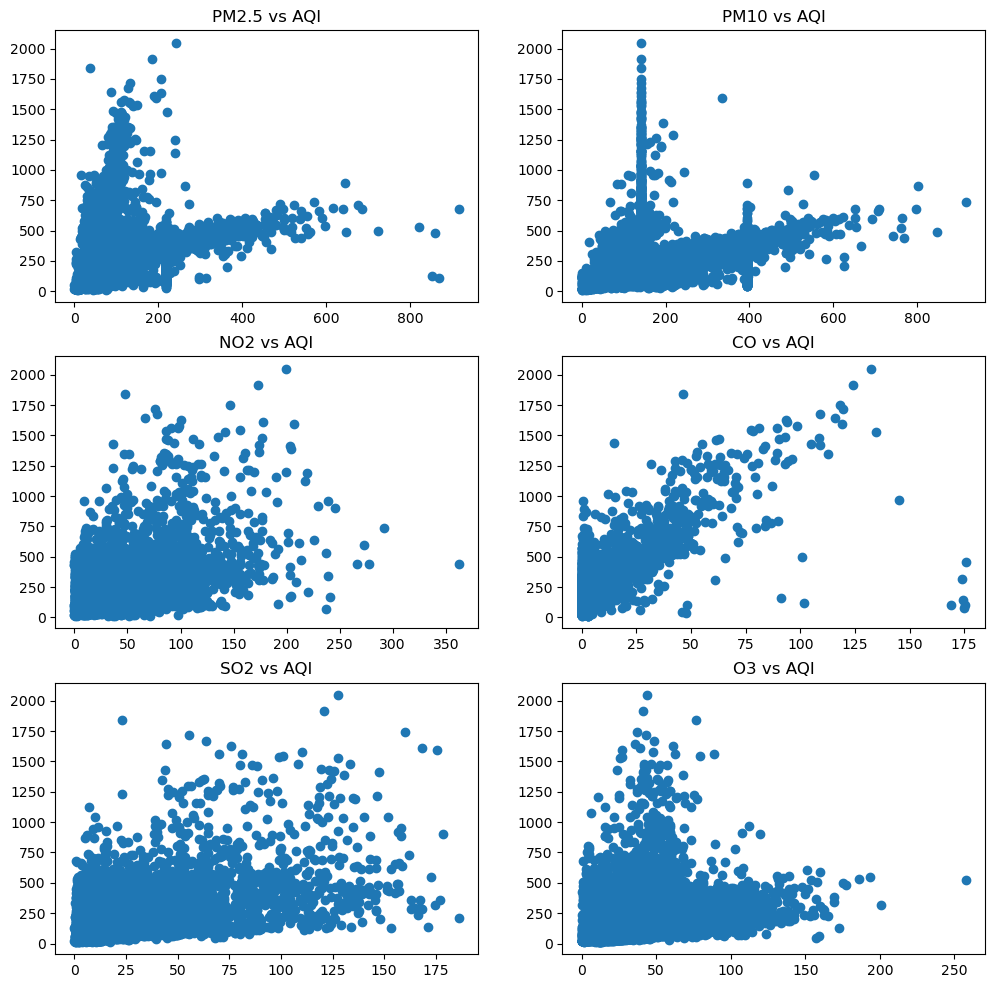

In [ ]:
subplot_features(df=df1)

In [ ]:
df1 = df1.dropna(subset=["AQI"])

In [ ]:
df1.isna().sum()

City        0
Date        0
AQI         0
PM2.5       0
PM10     1893
NO2         0
CO          0
SO2         0
O3        153
dtype: int64

In [ ]:
df1[df1.isna().any(axis=1)]["City"].unique()

array(['Ernakulam', 'Lucknow'], dtype=object)

In [ ]:
df1 = df1.dropna(subset=["PM10", "O3"])

In [ ]:
df1.isna().sum()

City     0
Date     0
AQI      0
PM2.5    0
PM10     0
NO2      0
CO       0
SO2      0
O3       0
dtype: int64

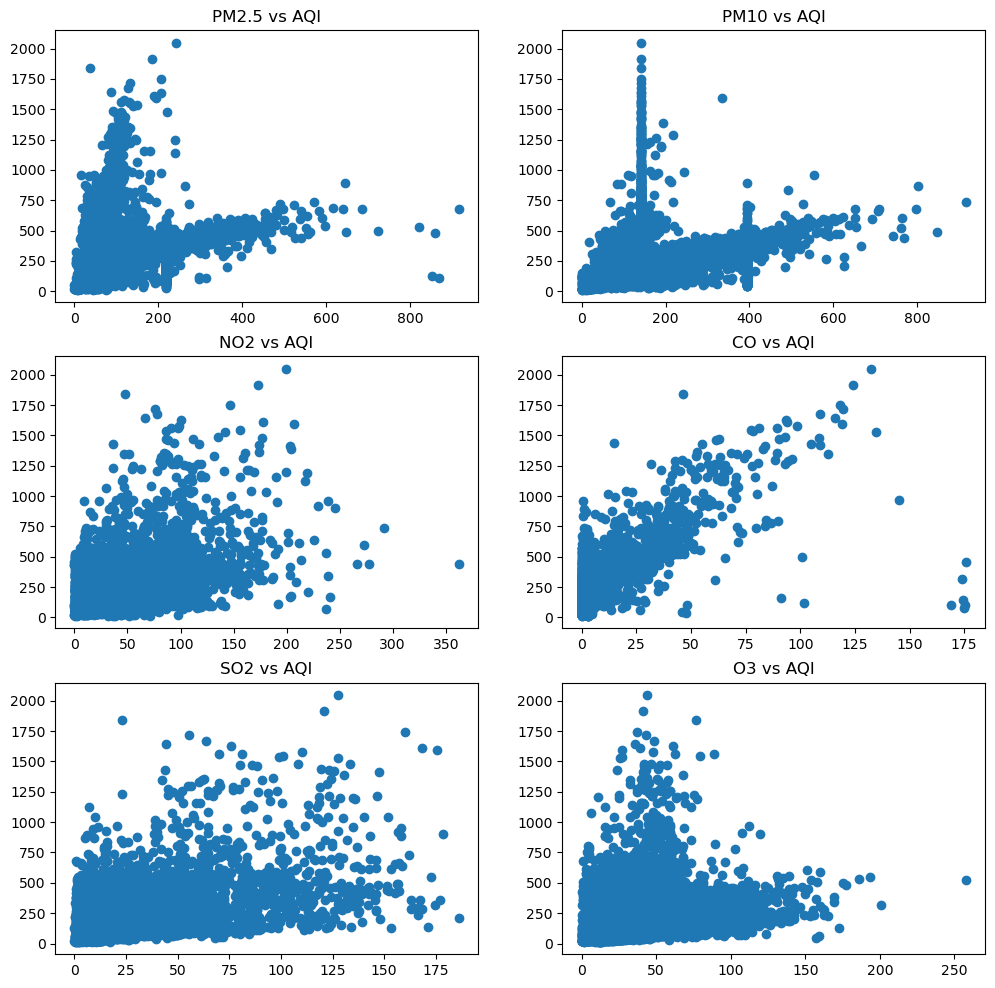

In [ ]:
subplot_features(df=df1)

In [ ]:
def remove_outlier_IQR(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    df_out = df.loc[(df[col] > lower_bound) & (df[col] < upper_bound)]
    return df_out


for column in col:
    df1 = remove_outlier_IQR(df1, column)

df1.shape

(15939, 9)

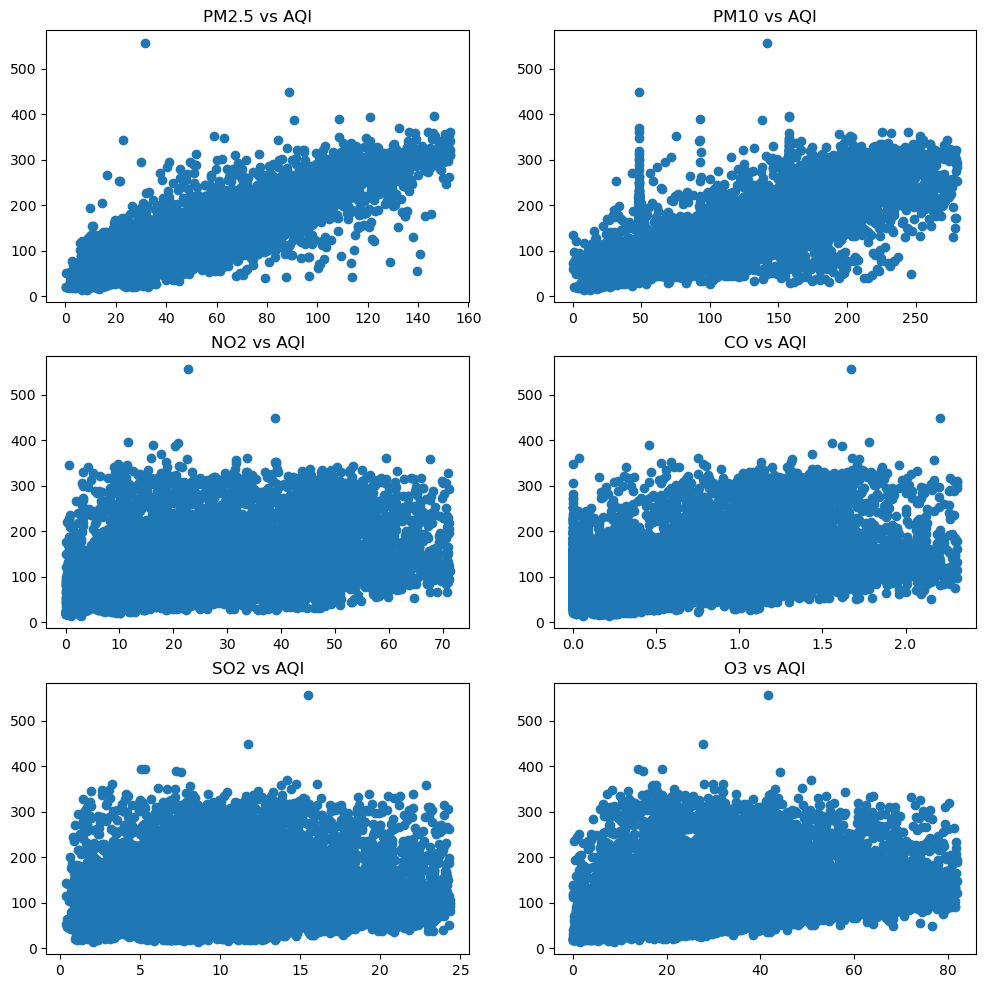

In [ ]:
subplot_features(df=df1)

## Model Training and Experimentation

1. We will split our cleaned dataset into train-test dataset
2. For each model we're going to visualize it's `prediction`, `errors`, `loss`, `metrics`.
3. For model loss: `MSE`, metrics: `RMSE`
4. We willl stick `Adam()` optimizers
5. To prevent model overfitting we're going `EarlyStoppingCallabacks()` provided by tensorflow


In [ ]:
df1.to_csv("city-aqi-reduced.csv", index=False)

In [ ]:
df1 = pd.read_csv("city-aqi-reduced.csv", low_memory=False)

In [ ]:
X = df1.drop(labels=["City", "Date", "AQI"], axis=1)
y = df1["AQI"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12751, 6), (3188, 6), (12751,), (3188,))

In [ ]:
es_1 = tf.keras.callbacks.EarlyStopping(
    monitor="root_mean_squared_error",
    patience=2,
    verbose=1,
)

In [ ]:
history_li = list()
color_li = list()

In [ ]:
from types import LambdaType
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot


def model_plot(y_test, y_preds, history_li=history_li, colors=color_li):
    fig, ax = plt.subplots(3, 2, figsize=(12, 12))  # Create a 2x2 grid of subplots

    # Subplot 1: Scatter plot of true vs predicted values
    ax[0, 0].scatter(
        y_test, y_preds, cmap="Blues", alpha=0.5, label="predicted-vs-true"
    )
    ax[0, 0].plot(y_test, y_test, color="red", linestyle="--", label="linear-fit")
    ax[0, 0].set_title("AQI Regression Model")
    ax[0, 0].set_xlabel("True Value")
    ax[0, 0].set_ylabel("Predicted Value")
    ax[0, 0].legend()

    # Subplot 2: KDE plot of true and predicted values distribution
    sns.kdeplot(
        y_preds, color="blue", fill=True, alpha=0.5, ax=ax[0, 1], label="predicted"
    )
    sns.kdeplot(y_test, color="red", fill=True, alpha=0.5, ax=ax[0, 1], label="true")
    ax[0, 1].set_title("Values Distribution")
    ax[0, 1].set_xlabel("Continuous Value")
    ax[0, 1].set_ylabel("Density")
    ax[0, 1].legend()

    # Subplot 3: Q-Q plot of error distribution
    residuals = y_test - y_test
    stats.probplot(residuals, dist="norm", plot=ax[1, 0])
    ax[1, 0].set_title("Q-Q Plot")

    # Subplot 4: Residual ranged barplot
    ranges = [(i, i + 25) for i in range(0, 500, 25)]
    means = []
    std_devs = []

    for lower, upper in ranges:
        mask = (y_test >= lower) & (y_test < upper)
        errors = np.abs(y_test[mask] - y_preds[mask])
        means.append(np.mean(errors))
        std_devs.append(np.std(errors))

    ax[1, 1].errorbar(
        [np.mean(r) for r in ranges], means, yerr=std_devs, fmt="o", capsize=5
    )
    ax[1, 1].set_xlabel("AQI Range")
    ax[1, 1].set_ylabel("Mean Absolute Error")
    ax[1, 1].set_title("Error Bar Plot of Mean Absolute Error by AQI Range")
    ax[1, 1].grid(True)

    # Subplot 5: Model comparison (rmse over epochs)
    ax[2, 0].set_title("Model Comparison")
    ax[2, 0].set_xlabel("Epochs")
    ax[2, 0].set_ylabel("RMSE")
    if history_li and colors:
        for i, history in enumerate(history_li, start=1):
            ax[2, 0].plot(
                history.history["root_mean_squared_error"],
                color=colors[i - 1],
                label=f"Model-{i} rmse",
            )
        ax[2, 0].legend()

    # Subplot 6: Model comparison (loss over epochs)
    ax[2, 1].set_title("Model Comparison")
    ax[2, 1].set_xlabel("Epochs")
    ax[2, 1].set_ylabel("Loss")
    if history_li and colors:
        for i, history in enumerate(history_li, start=1):
            ax[2, 1].plot(
                history.history["loss"], color=colors[i - 1], label=f"Model-{i} loss"
            )
        ax[2, 1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
tf.random.set_seed(7)
model_1 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(1, activation="relu"),
    ]
)

model_1.compile(
    loss=tf.keras.losses.mse,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

history_1 = model_1.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[es_1])
history_li.append(history_1)
color_li.append("magenta")

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 15677.1016 - root_mean_squared_error: 125.2030
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 15677.1016 - root_mean_squared_error: 125.2030
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 15677.1016 - root_mean_squared_error: 125.2030
Epoch 3: early stopping


In [ ]:
model_1.evaluate(X_test, y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16032.0928 - root_mean_squared_error: 126.5904


[15670.16015625, 125.18051147460938]

In [ ]:
y_preds_1 = model_1.predict(X_test).squeeze()

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


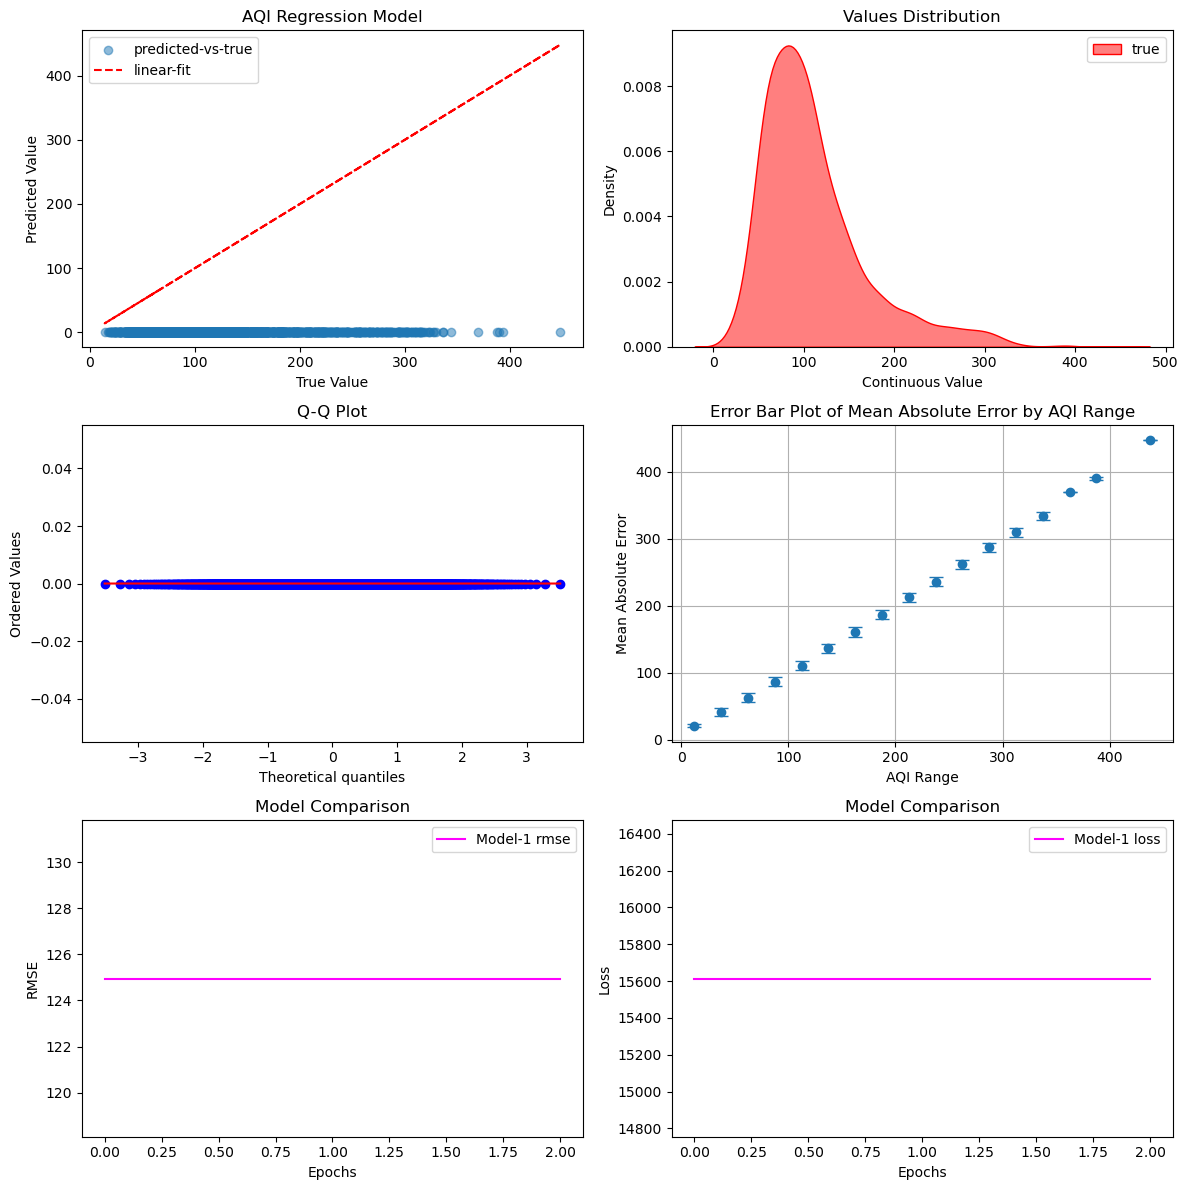

In [ ]:
model_plot(y_test, y_preds_1)

In [ ]:
model_2 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(12, activation="relu"),
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(1, activation="relu"),
    ]
)

model_2.compile(
    loss=tf.keras.losses.mse,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

history_2 = model_2.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[es_1])
history_li.append(history_2)
color_li.append("coral")

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 3808.3691 - root_mean_squared_error: 59.8510
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 770.3204 - root_mean_squared_error: 27.7501
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 721.1356 - root_mean_squared_error: 26.8447
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 706.2327 - root_mean_squared_error: 26.5651
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 695.5684 - root_mean_squared_error: 26.3636
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 686.7942 - root_mean_squared_error: 26.1967
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 679.1302 - root_mean_squared_error: 26.0503
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 672.4999 - root_mean_squared_error: 25.9228
Epoch 9/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 666.3232 - root_mean_squared_error: 25.8036
Epoch 10/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step 

In [ ]:
model_2.evaluate(X_test, y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 588.9947 - root_mean_squared_error: 24.2650


[625.95458984375, 25.019084930419922]

In [ ]:
y_preds_2 = model_2.predict(X_test).squeeze()

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


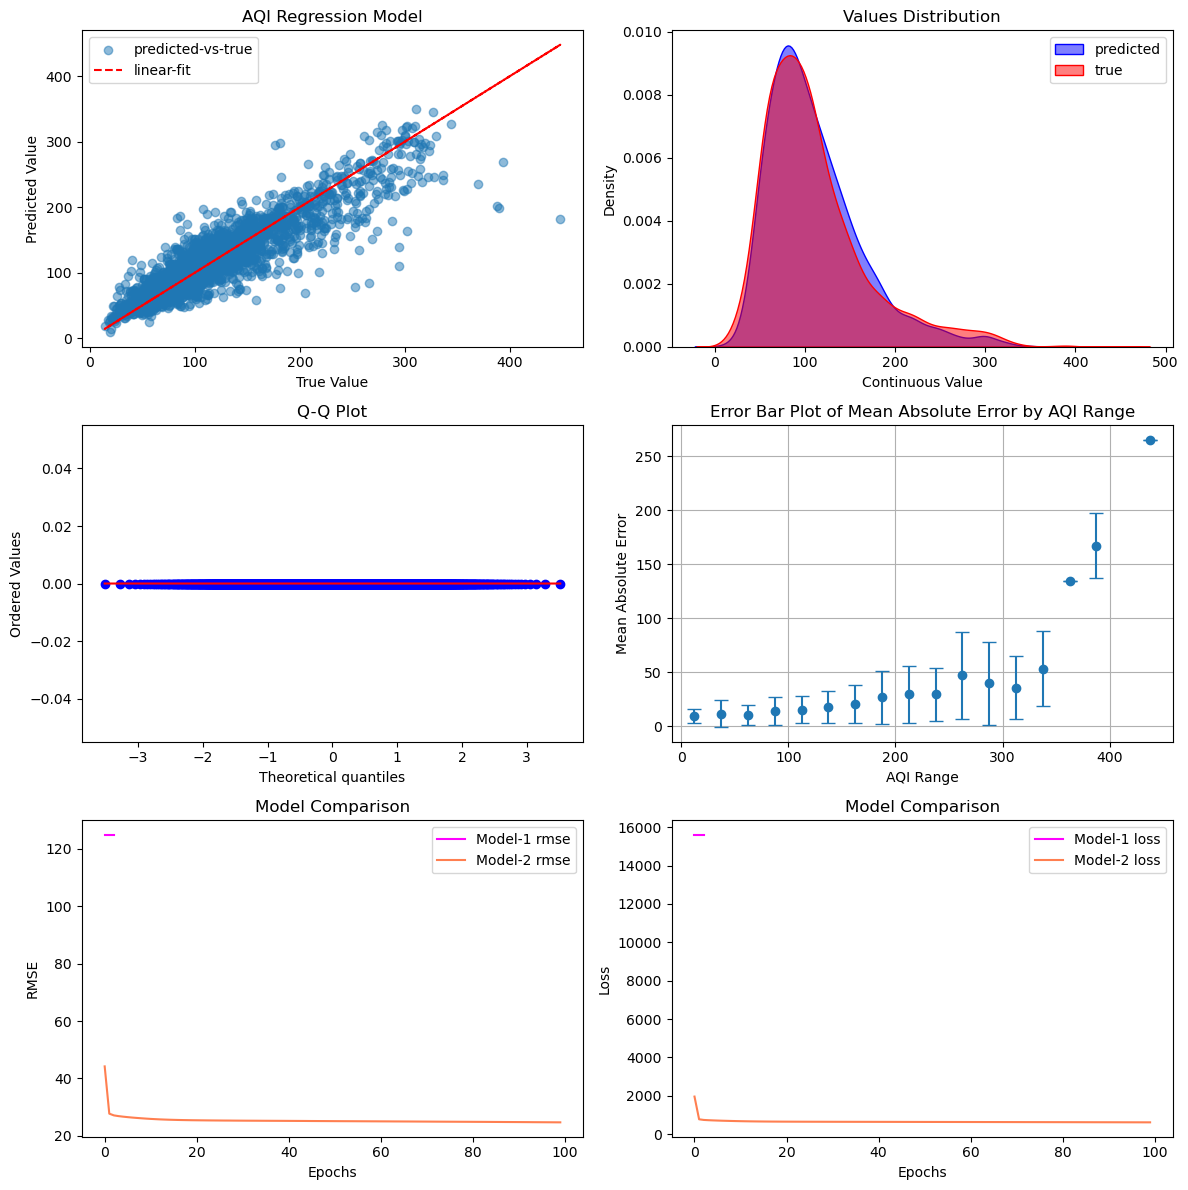

In [ ]:
model_plot(y_test, y_preds_2)

In [ ]:
es_2 = tf.keras.callbacks.EarlyStopping(
    monitor="root_mean_squared_error", patience=3, verbose=1
)

In [ ]:
tf.random.set_seed(7)
model_3 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(12, activation="relu"),
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(3, activation="relu"),
        tf.keras.layers.Dense(1, activation="relu"),
    ]
)

model_3.compile(
    loss=tf.keras.losses.mse,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

history_3 = model_3.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[es_2])
history_li.append(history_3)
color_li.append("royalblue")

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3919.9016 - root_mean_squared_error: 60.8882
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 821.3441 - root_mean_squared_error: 28.6559
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 742.5244 - root_mean_squared_error: 27.2406
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 724.2108 - root_mean_squared_error: 26.9019
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 709.7112 - root_mean_squared_error: 26.6307
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 696.9845 - root_mean_squared_error: 26.3905
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 686.7588 - root_mean_squared_error: 26.1960
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 679.0573 - root_mean_squared_error: 26.0488
Epoch 9/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 673.0786 - root_mean_squared_error: 25.9342
Epoch 10/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

In [ ]:
model_3.evaluate(X_test, y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 582.4666 - root_mean_squared_error: 24.1302


[618.1835327148438, 24.863296508789062]

In [ ]:
y_preds_3 = model_3.predict(X_test).squeeze()

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


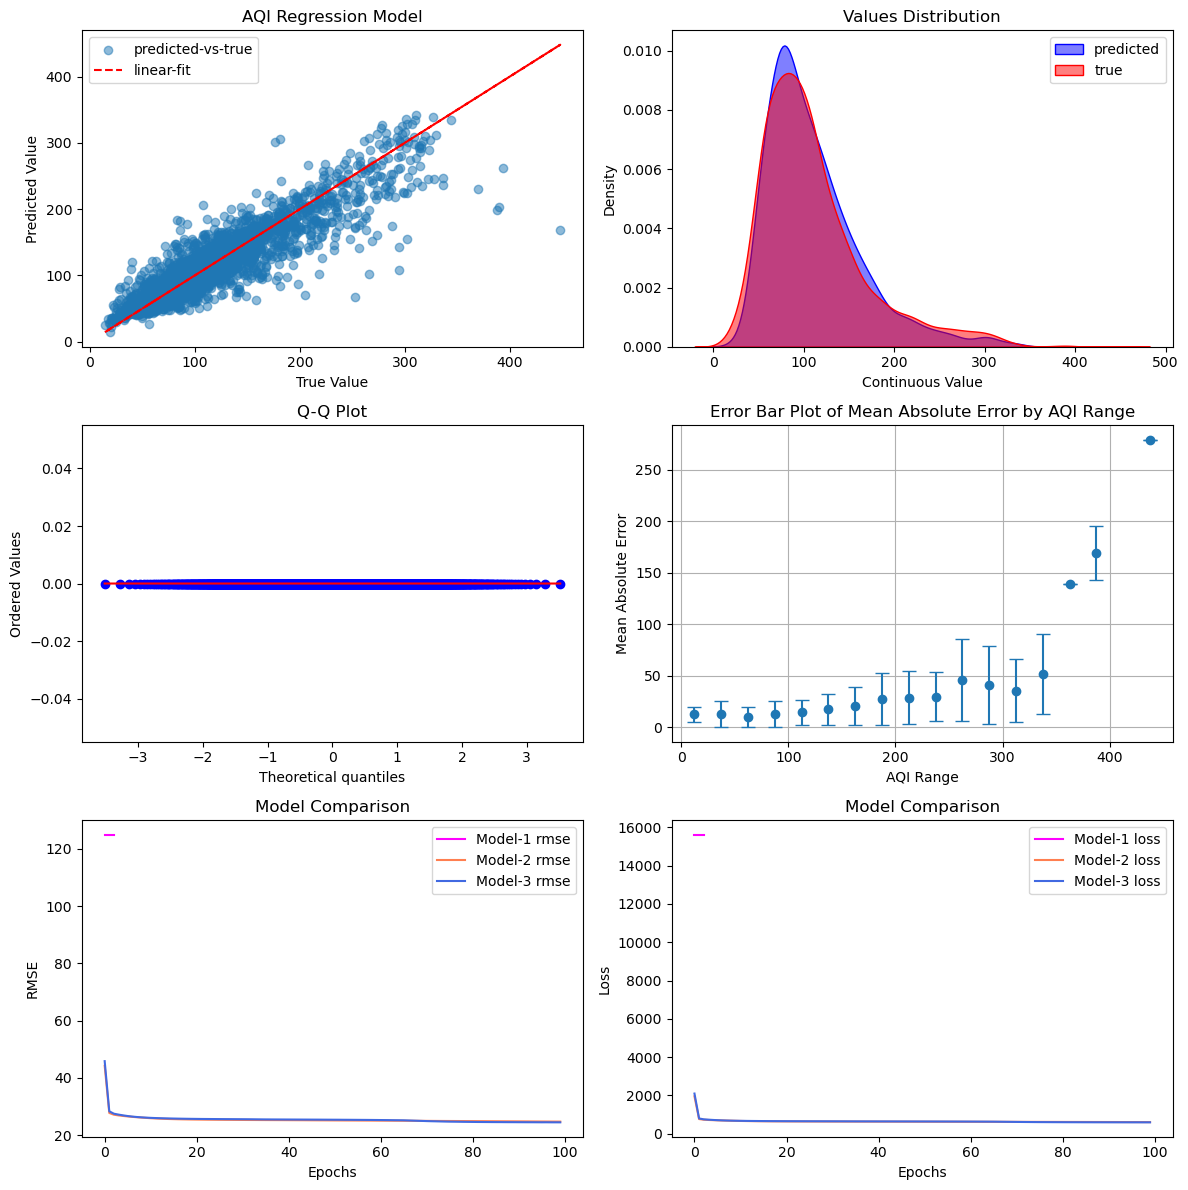

In [ ]:
model_plot(y_test, y_preds_3)

## Model Saving and testing

1. After testing model formats like: `${model}.keras`, `${model}.h5`, `${model}(zip)`. `.h5` format models works well with streamlit.
2. Model nomenclature would be based on total_params
3. After model visulization, we'll save the model


In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 275 (1.08 KB)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 184 (740.00 B)

In [ ]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │              84 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 509 (1.99 KB)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 340 (1.33 KB)

In [ ]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 12)                  │              84 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 563 (2.20 KB)

 Trainable params: 187 (748.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 376 (1.47 KB)

In [ ]:
import pydot

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
plot_model(model_1, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
plot_model(model_1, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
plot_model(model_2, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
plot_model(model_3, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
model_1.save("model_91.h5")
model_2.save("model_169.h5")
model_3.save("model_187.h5")